In [1]:
import os
import gc
import asyncio
from typing import Type
from dotenv import load_dotenv
env_file = "~/.config/pyenvs/monitor.env"
load_dotenv(os.path.expanduser(env_file))

from connector.monitor import Monitor
from connector.connector import BaseConnector
from connector.binance.binance_perp import BinancePerp
from connector.binance.binance_spot import BinanceSpot
import connector.visualization as visual

print(f"PID: {os.getpid()}")
connector_type_list: list[Type[BaseConnector]] = [BinancePerp, BinanceSpot]  # , BinanceSpot
m = Monitor(connector_type_list=connector_type_list)
gc.disable()
task = asyncio.create_task(m.run())

PID: 1814438


In [3]:
task.cancel()  # отправляем CancelledError в run()
await task 

In [27]:
import pandas as pd
from typing import Any
# from connector.kline_service import KlinesContainer

rows: list[dict[str, Any]] = []
for symbol, trade_container in m.connectors[BinancePerp].kline_service.containers.items():
    trades = trade_container.klines_1m
    idx = trades.idx
    idx0 = (idx + 1) % trades.size if trades.wrapped else 0

    price_close = trades.prices[idx]
    price_open = trades.prices[idx0]
    delta = round((price_close / price_open - 1) * 100, 1)

    price_close_spot: float | None = None
    #container = m.connectors[BinanceSpot].kline_service.containers.get(symbol)
    #if isinstance(container, KlinesContainer):
    #    trades_spot = container.klines_1m
    #    price_close_spot = trades_spot.prices[trades_spot.idx]
    #diff = round(100 * (price_close_spot / price_close - 1), 1) if price_close_spot else None
    diff = 0.0 * price_close

    if price_close != price_open:
        rows.append({"symbol": symbol, "price_open": price_open, "price_close": price_close, "price_close_spot": price_close_spot, "delta": delta, "diff": diff})

df = pd.DataFrame(rows)
df.sort_values("delta", ascending=False).head(20)

,symbol,price_open,price_close,price_close_spot,delta,diff
472,LABUSDT,1.468800,2.798100,None,90.5,0.0
224,FHEUSDT,0.024740,0.046300,None,87.1,0.0
134,DOGSUSDT,0.000036,0.000064,None,77.3,0.0
36,MUSDT,2.732200,3.497500,None,28.0,0.0
67,TONUSDT,1.568000,1.954200,None,24.6,0.0
488,HIVEUSDT,0.059890,0.074230,None,23.9,0.0
163,ZECUSDT,419.810000,516.070000,None,22.9,0.0
515,GWEIUSDT,0.108570,0.130920,None,20.6,0.0
283,AINUSDT,0.087250,0.102700,None,17.7,0.0
519,NOTUSDT,0.000442,0.000519,None,17.4,0.0


In [ ]:
import importlib
importlib.reload(visual)

<module 'connector.visualization' from '/home/inevity/projects/monitor/src/connector/visualization.py'>

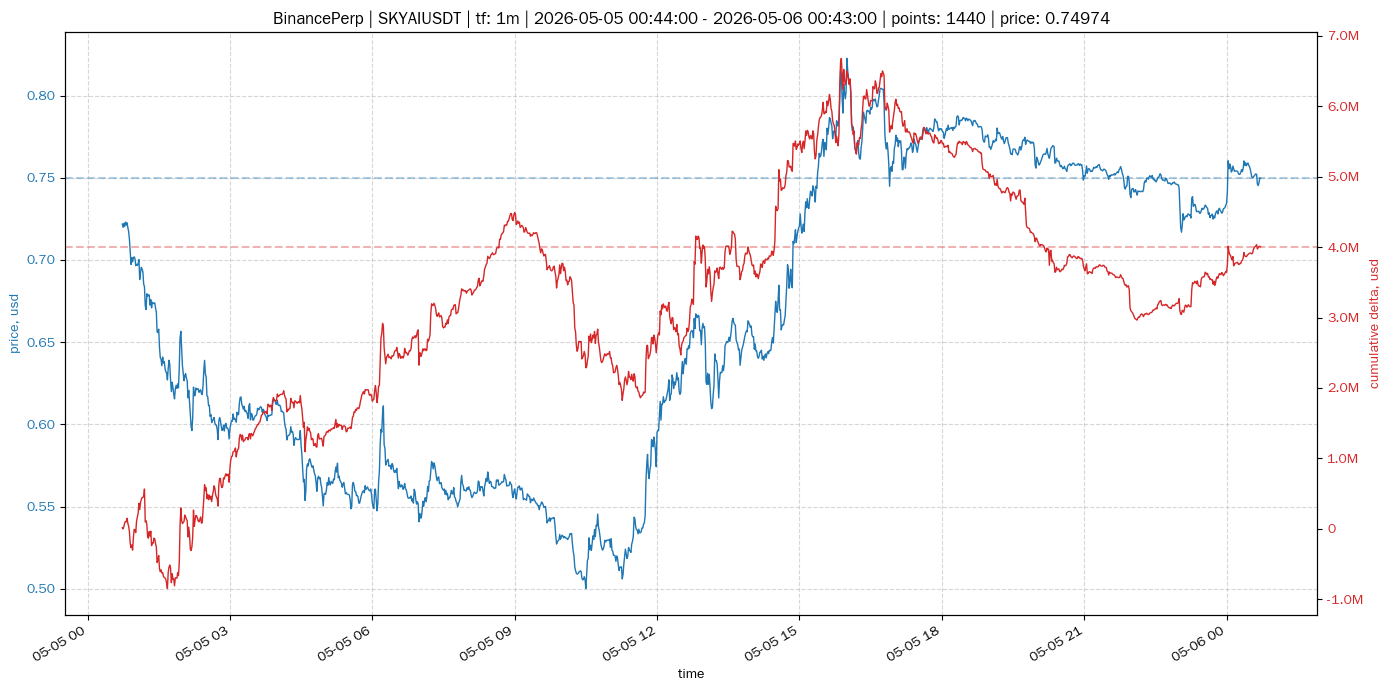

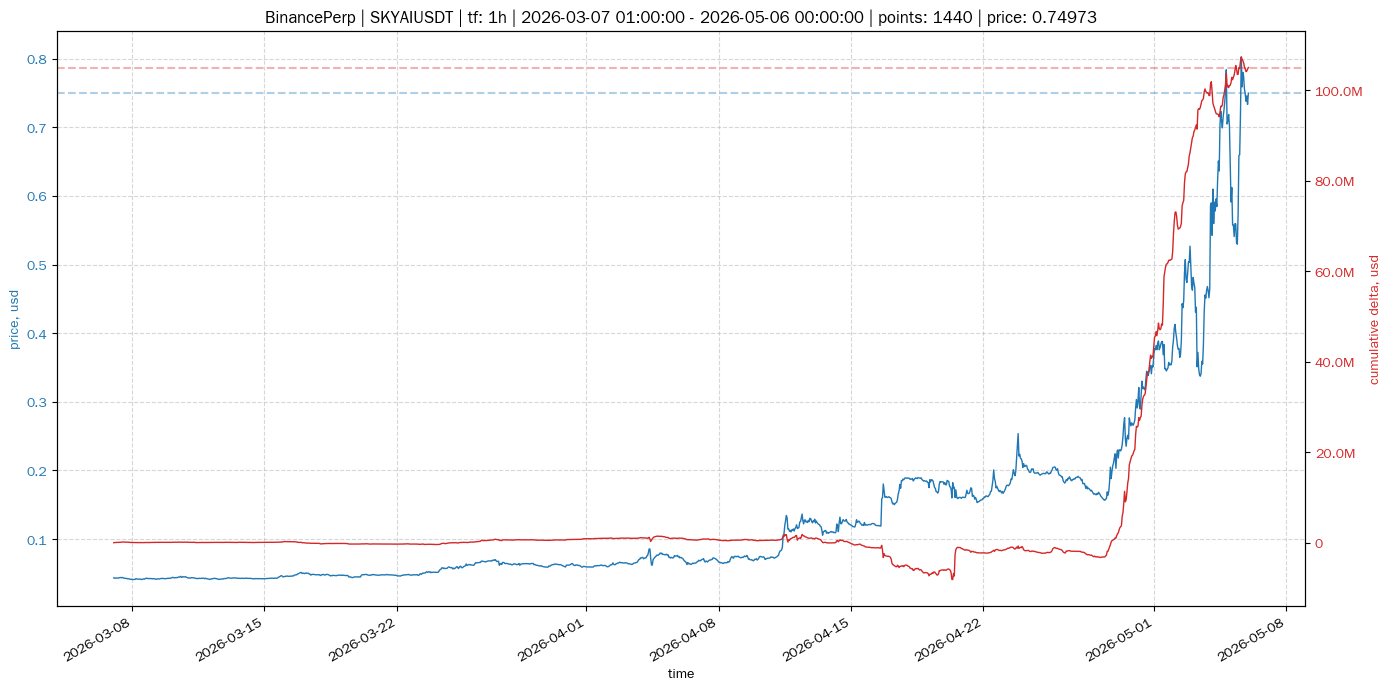

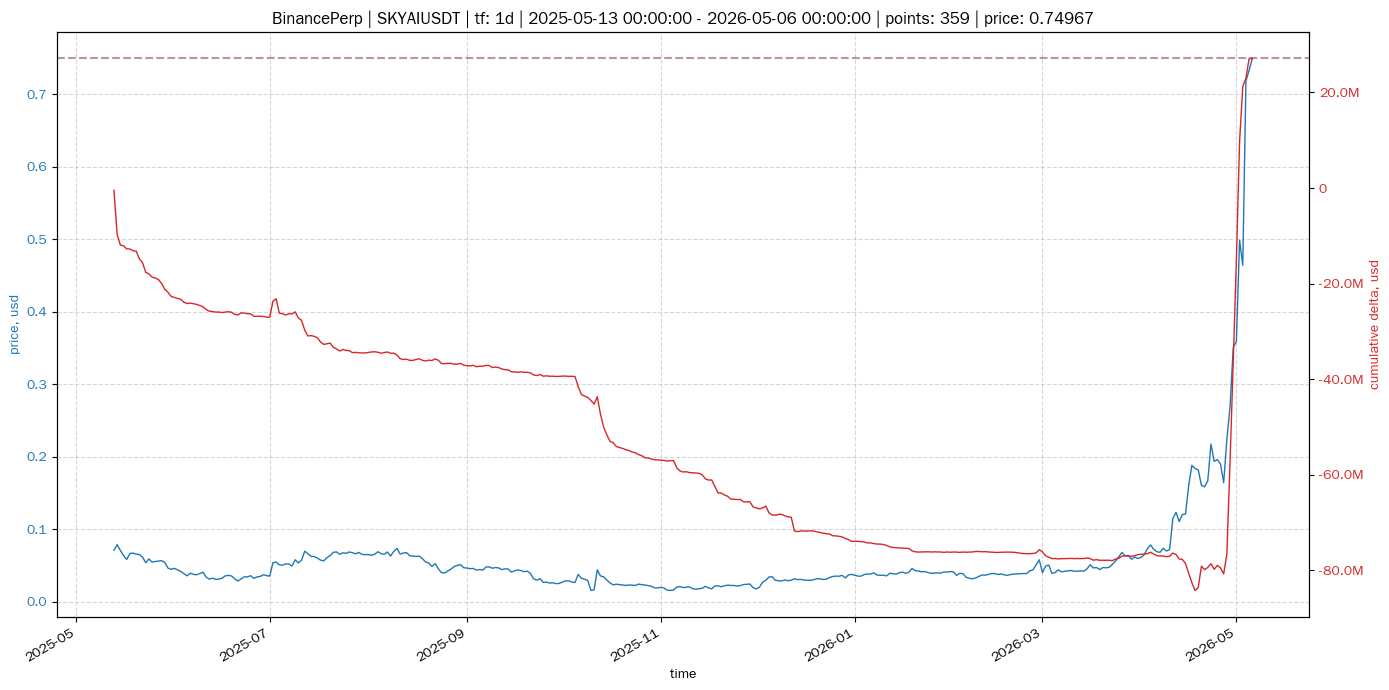

In [2]:
symbol = "SKYAIUSDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1m", "20260503 20:59")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1h", "20250503 20:59")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1d")

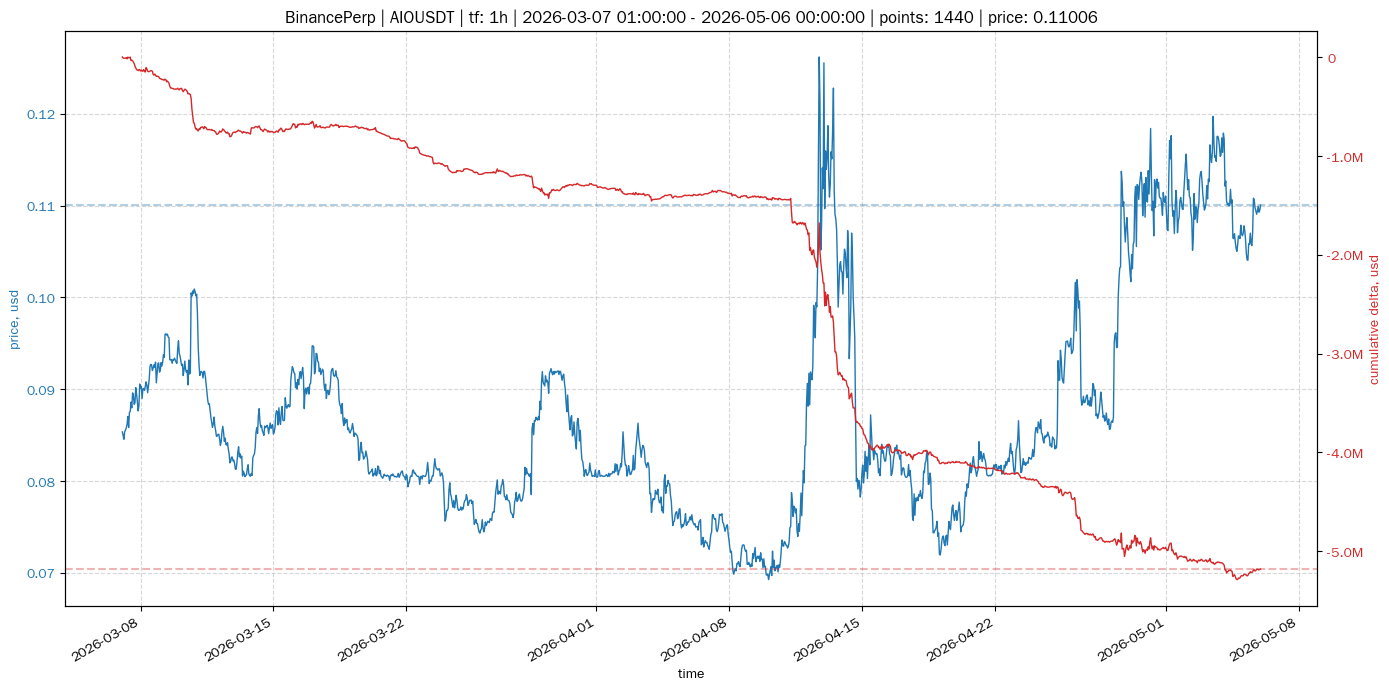

In [3]:
symbol = "AIOUSDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1h", "20250413 16:00")

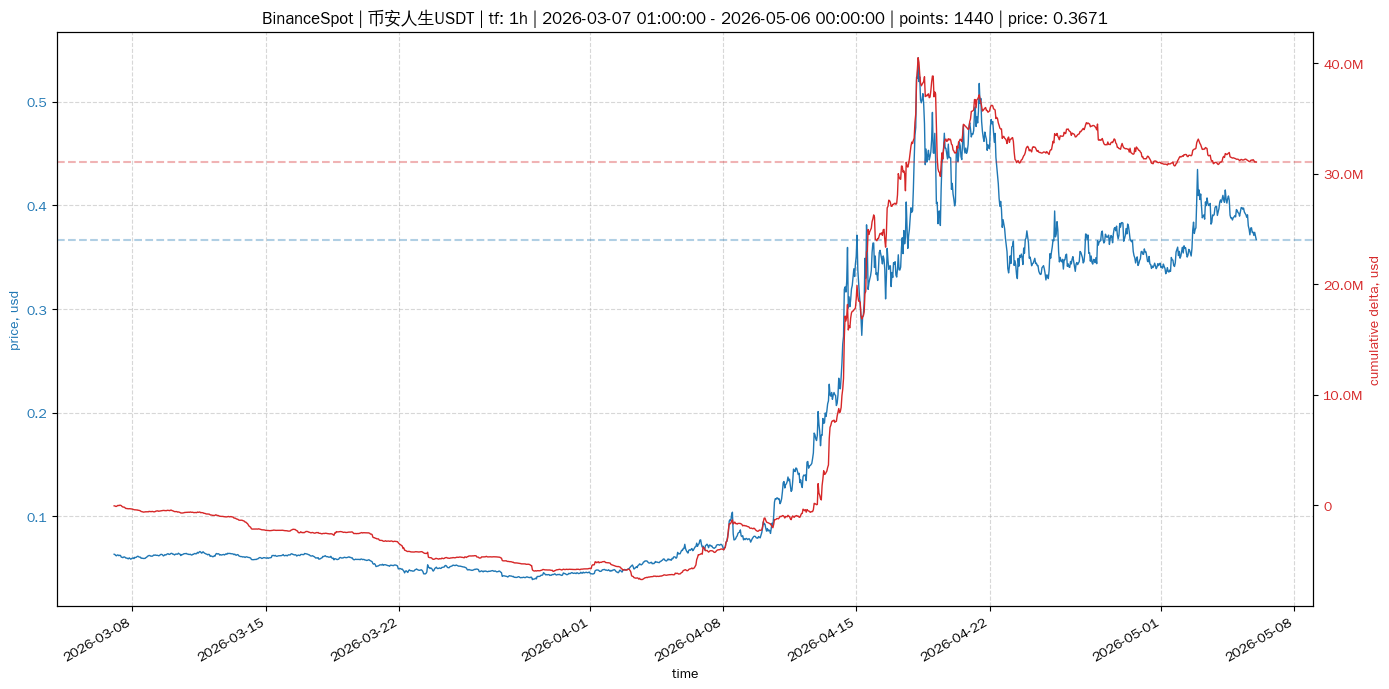

In [4]:
symbol = "币安人生USDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinanceSpot], "1h", "20250502 16:00")

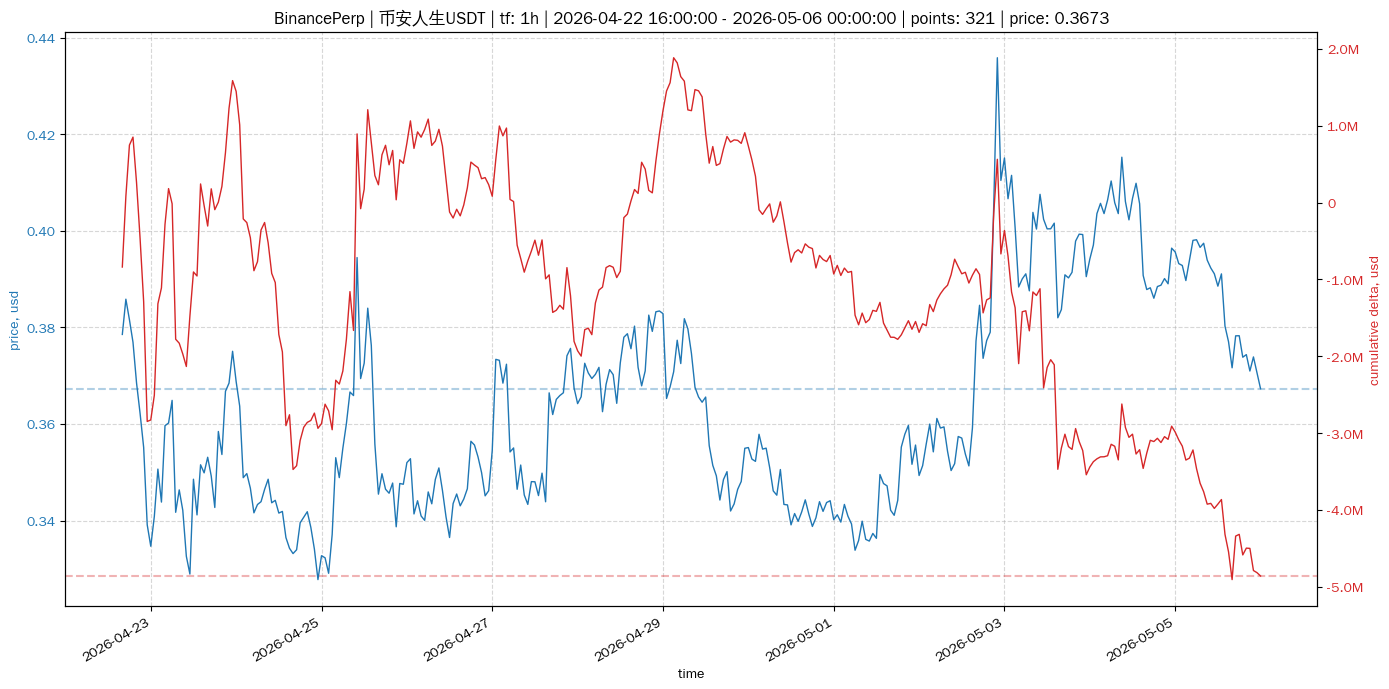

In [5]:
symbol = "币安人生USDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1h", "20260422 16:00")

In [ ]:
import numpy as np
symbol = "币安人生USDT"
public_trades = m.connectors[BinancePerp].trade_service[symbol].public_trades_1m
idx = public_trades.idx
prices = public_trades.prices
size = len(public_trades)
p = np.concatenate([prices[idx+1:size], prices[:idx]])

tp = round((np.min(p) + np.max(p))/2, 8)
sl = round(np.max(np.diff(p)) * 2 + np.max(p), 8)
price = prices[idx]
rr = round((price-tp)/(sl-price), 2)

print(price, np.max(p), tp, sl, rr)

0.44856 0.51226 0.43548 0.5706 0.11


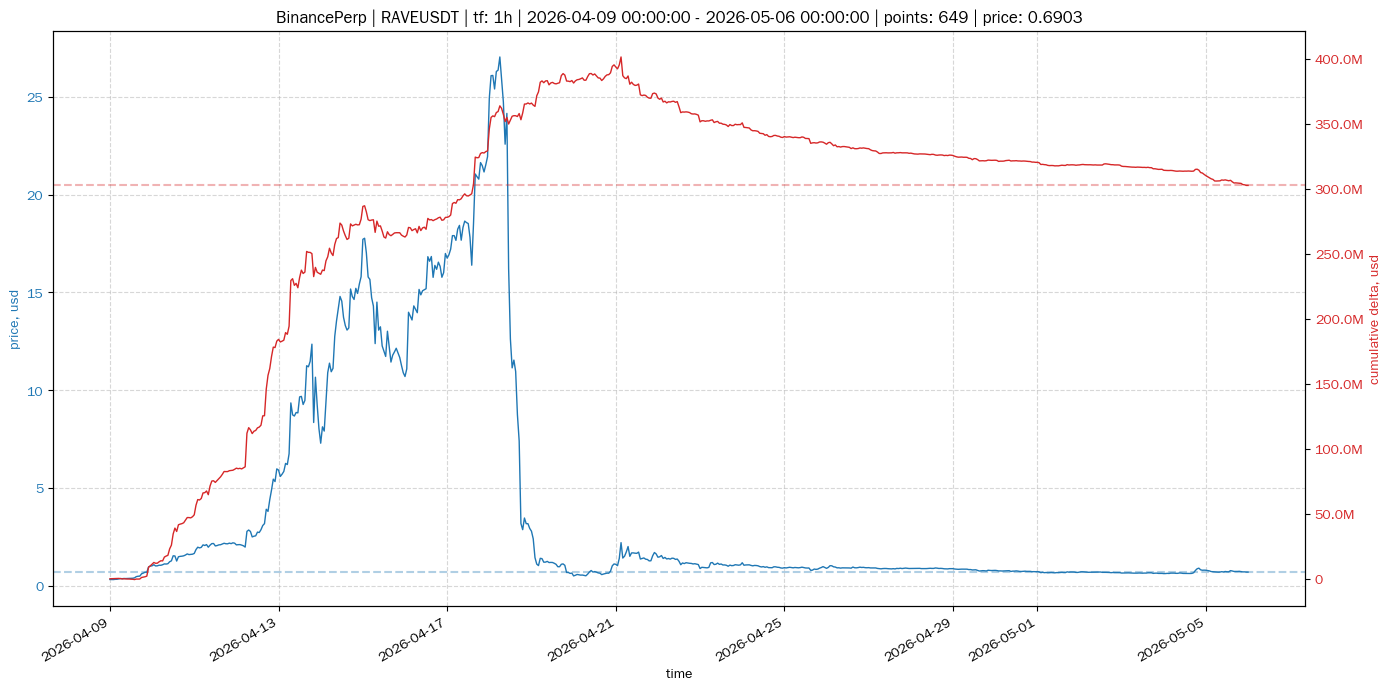

BinanceSpot RAVEUSDT: буфер пуст


In [15]:
symbol = "RAVEUSDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1h", "20260409")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinanceSpot], "1h")

In [ ]:
import numpy as np
tss = m.connectors[BinancePerp].trade_service["RAVEUSDT"].public_trades_1m.timestamps
ts = np.min(tss)
print(np.datetime64(int(ts), "ms"), len(tss))


2026-04-12T17:47:00.000 1440


In [ ]:
import numpy as np
tss = m.connectors[BinancePerp].trade_service["RAVEUSDT"].public_side_trades.timestamps
ts = np.min(tss)
print(np.datetime64(int(ts), "ms"), len(tss))

2026-04-13T17:36:46.046 10000


In [ ]:
symbol = "GWEIUSDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1m")

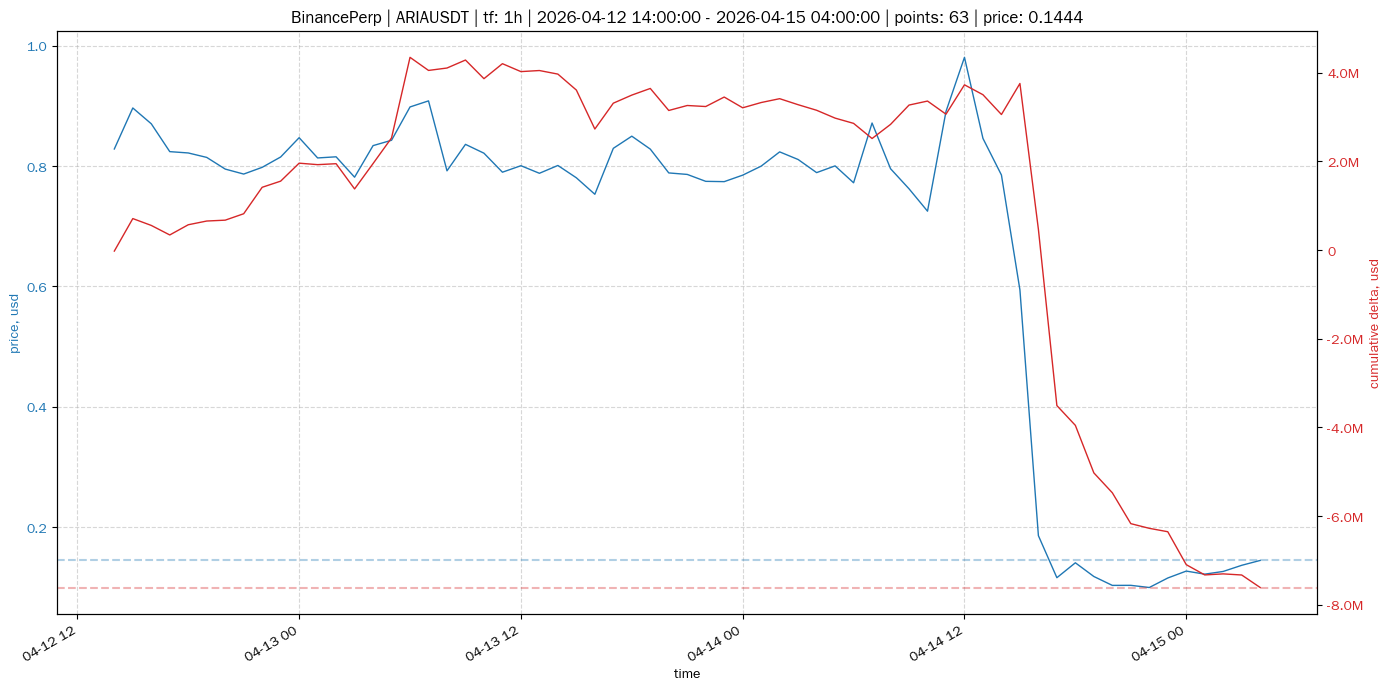

ARIAUSDT: буфер пуст


In [ ]:
symbol = "ARIAUSDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1h")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinanceSpot], "1h")

In [ ]:
symbol = "TONUSDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1m")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinanceSpot], "1m")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1h")

In [ ]:
symbol = "IDUSDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1s")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinanceSpot], "1s")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1m", "20260410 23:00")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinanceSpot], "1m", "20260410 23:00")

In [ ]:
import importlib

from config import bi_api_key as api_key, bi_secret_key as secret_key
import bi_exchange as bi
import aiohttp

importlib.reload(bi)

symbol = "AIAUSDT"
optimal_f = 0.02


async with aiohttp.ClientSession() as session:
    response, _ = await bi.http_request(
        method=bi.HTTPMethod.GET, session=session, url=bi.url_future_base + "v3/account", params={}, api_key=api_key, secret_key=secret_key
    )
    equity = float(response["totalWalletBalance"])

print(equity)

perp = perps[symbol]
brackets = perp.features["brackets"]
feature = perp.features["1s"]
prices = np.abs(feature["last_price"].get_data())
current_price = round(float(prices[-1]) // perp.price_step * perp.price_step, perp.price_precision)
max_price = round(float(np.max(prices)) // perp.price_step * perp.price_step, perp.price_precision)
# max_price = round(float(20.3)//perp.price_step*perp.price_step, perp.price_precision)
sl_value = round(equity * optimal_f)
sl_liq_target = round(sl_value * 1.25)
qty = round(sl_value / (max_price - current_price) // perp.qty_step * perp.qty_step, perp.qty_precision)
position_amount = qty * current_price
liquidationFee = perp.features["liquidationFee"]

max_initial_leverage: int = 1
for row in brackets:
    if row["notionalFloor"] < position_amount < row["notionalCap"]:
        max_initial_leverage = row["initialLeverage"]
        mmr = row["maintMarginRatio"]
        mma = row["cum"]


leverage = 1 / ((sl_liq_target + mma) / position_amount + mmr + liquidationFee)

print(f"price: {current_price}, hi: {max_price}, sl: {sl_value}, sl_liq： {sl_liq_target}, qty: {qty}, pos_value: {position_amount}, lev: {leverage}, max_lev: {max_initial_leverage}")

params = {
    "symbol": symbol,
    "side": "SELL",
    "type": "limit",
    "timeInForce": "GTX",
    "reduceOnly": "false",
    "price": str(current_price),
    "quantity": str(qty),
    "stopPrice": str(max_price),
    # "newClientOrderId": order.custom_id,
}

In [ ]:
plot_price_and_cumulative_delta_notional(
    symbol="PLAYUSDT",
    connector=m.connectors[BinancePerp],
    feature="1m",
    from_date_utc="2026-04-08T01:50:00",
    resistance_bucket="15min",
    resistance_bps_floor=1.0,
    resistance_min_blocks=3,
    resistance_ewm_span=6,
    volume_is_notional=False,
)

In [ ]:
perp_symbols = set(instrument.unified_symbol for instrument in m.connectors[BinancePerp].instrument_manager.values())
spot_symbols = set(instrument.unified_symbol for instrument in m.connectors[BinanceSpot].instrument_manager.values())
unified_symbols = perp_symbols & spot_symbols
len(perp_symbols), len(spot_symbols), len(unified_symbols)

(542, 439, 371)

In [ ]:
import numpy as np
symbol = "币安人生USDT"
public_trades = m.connectors[BinancePerp].trade_service[symbol].public_trades_1m
idx = public_trades.idx
prices = public_trades.prices
size = len(public_trades)
p = np.concatenate([prices[idx+1:size], prices[:idx]])

tp = round((np.min(p) + np.max(p))/2, 8)
sl = round(np.max(np.diff(p)) * 2 + np.max(p), 8)
price = prices[idx]
rr = round((price-tp)/(sl-price), 2)

print(price, np.max(p), tp, sl, rr)

0.38813 0.52851 0.44869 0.58107 -0.31


In [ ]:
from datetime import datetime, timezone

s = "20260419 12:00"

a = int(datetime.fromisoformat(s).timestamp() * 1000)
b = int(datetime.fromisoformat(s).replace(tzinfo=timezone.utc).timestamp() * 1000)

print(a, b, a - b)

1776564000000 1776600000000 -36000000


In [ ]:
from datetime import datetime

now_local = datetime.now().astimezone()

print("local datetime:", now_local)
print("tzinfo:", now_local.tzinfo)
print("utc offset:", now_local.utcoffset())

local datetime: 2026-04-19 18:31:34.987599+10:00
tzinfo: +10
utc offset: 10:00:00
